# Cohort FACTM — Su COVID-19 multi-omics

Real-data version of `cohort_tests copy.ipynb`. Two views (metabolic + proteomic) are
loaded via `covid_data.load_covid.load_covid(...)` and fed into the same `fit_cohort` /
`fit_baseline` pipeline. Three cohort partitions are evaluated:

* **per_severity** — one cohort per WHO Ordinal Scale value (up to 8 cohorts).
* **grouped**      — 3 groups: `0-1` (mild) / `2-4` (moderate) / `5-7` (severe).
* **binary**       — 2 groups: `0-2` (non_hosp) / `3-7` (hosp).

Experiments 1–3 inspect `E[gamma]` and `E[gamma·delta]` heatmaps directly per partition.
Experiments 4–6 are adapted from `w_loading_tests.ipynb` and `cohort_tests copy.ipynb`
for the real-data setting where ground-truth `Z`/`W` are unknown:

* **Exp 4 — Cohort distance structure.** Pairwise L2 distances between cohort positions
  in latent space (`E[gamma·delta]`), one heatmap per partition.
* **Exp 5 — Distance vs ordinal severity (key distance test).** For ordered partitions
  (`per_severity`, `grouped`), correlate latent cohort distance with absolute WHO-scale
  difference. A correctly fit cohort prior should preserve the severity gradient.
* **Exp 6 — W loadings stability cohort vs baseline.** Hungarian-align factors via Z,
  then `|corr(W_cohort, W_baseline)|` per factor per view. High values mean the cohort
  prior does not perturb which features drive each factor.


### Imports


In [9]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from src.views import Views

from covid_data.load_covid import load_covid


### Helpers: model fitting and cohort-effect extraction


In [27]:
def fit_cohort(views, K, pi=0.5, max_iter=100, seed=0):
    """Fit CohortFACTM with spike-and-slab cohort prior (ZPrior.COHORT)."""
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL,
                                              w_prior=WPrior.ARD_SS)
                              for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.COHORT] * K,
        cohort_prior_config=CohortPriorConfig(pi=pi),
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_baseline(views, K, max_iter=100, seed=0):
    """Fit standard FACTM with isotropic N(0,1) prior — no cohort structure."""
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL,
                                              w_prior=WPrior.ARD_SS)
                              for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.STD_NORMAL] * K,
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def extract_cohort_effects(model, cohort_labels, K):
    """Pull E[gamma] and E[delta] per (cohort, factor) from the fitted z-priors.

    No Hungarian alignment: there is no ground-truth Z for real data, so we just
    inspect the fitted matrices as-is. Cohort rows are ordered as the prior
    stored them (sorted alphabetically by label inside CohortZPrior).
    """
    priors = model.fa.node_z.z_priors
    E_g = np.column_stack([priors[k].E_gamma for k in range(K)])
    E_d = np.column_stack([priors[k].E_delta for k in range(K)])
    cohort_names = np.array(sorted(np.unique(cohort_labels)))
    return {
        'E_gamma': E_g,
        'E_delta': E_d,
        'cohorts': cohort_names,
        'elbo': float(model.elbo_sequence[-1]),
    }


def plot_cohort_effects(out, K, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(11, 0.55 * len(out['cohorts']) + 2))
    sns.heatmap(out['E_gamma'] * out['E_delta'], annot=True, fmt='.2f',
                cmap='coolwarm', center=0,
                xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[0])
    axes[0].set_title(f'{title_prefix} — E[gamma·delta]')
    sns.heatmap(out['E_gamma'], annot=True, fmt='.2f',
                cmap='Blues', vmin=0, vmax=1,
                xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[1])
    axes[1].set_title(f'{title_prefix} — E[gamma]')
    plt.tight_layout()
    plt.show()


# --------- Distance / Hungarian / W-stability helpers (Exp 4–6) ---------

def cohort_dist(M):
    """Pairwise L2 distance between rows of M (cohort positions in latent space)."""
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


def hungarian(Z_a, Z_b):
    """Match columns of Z_b to columns of Z_a maximising sum of |corr|.

    Returns perm and signs so that Z_b[:, perm] * signs aligns column-wise with Z_a.
    Same algorithm as w_loading_tests; here we use it across two model fits.
    """
    K = Z_a.shape[1]
    corr = np.array([[np.corrcoef(Z_a[:, i], Z_b[:, j])[0, 1]
                      for j in range(K)] for i in range(K)])
    row, col = linear_sum_assignment(-np.abs(corr))
    signs = np.sign(corr[row, col])
    signs[signs == 0] = 1
    return col, signs.astype(float)


def w_stability(model_a, model_b, K):
    """Per-view per-factor |corr(W_a, W_b)| after Hungarian alignment on Z.

    High values across factors and views mean the cohort prior leaves the W
    feature space essentially unchanged compared to the STD_NORMAL baseline.
    """
    perm, signs = hungarian(model_a.get_latent_factors(),
                            model_b.get_latent_factors())
    out = []
    for v in range(len(model_a.fa.nodelist_w)):
        Wa = model_a.fa.nodelist_w[v].E_w
        Wb = model_b.fa.nodelist_w[v].E_w
        out.append(np.array([
            abs(np.corrcoef(Wa[:, k], Wb[:, perm[k]] * signs[k])[0, 1])
            for k in range(K)
        ]))
    return out, perm, signs


def severity_from_label(label):
    """Map a cohort label string back to a WHO-scale value (or midpoint).

    'sev0'..'sev7' -> 0..7
    'mild' / 'moderate' / 'severe' -> range midpoints (0-1, 2-4, 5-7)
    '0-1' / '2-4' / '5-7' -> range midpoint
    'non_hosp' -> 1.0 (midpoint of 0-2);  'hosp' -> 5.0 (midpoint of 3-7).
    """
    s = str(label).strip().lower()
    if s in ('mild', 'moderate', 'severe'):
        return {'mild': 0.5, 'moderate': 3.0, 'severe': 6.0}[s]
    if s.startswith('sev') and s[3:].isdigit():
        return float(s[3:])
    if '-' in s:
        a, b = s.split('-')
        return (float(a) + float(b)) / 2
    if s == 'non_hosp':
        return 1.0
    if s == 'hosp':
        return 5.0
    return float('nan')


# Populated by each experiment cell, consumed by Exp 4–6.
fits = {}


## Experiment 1 — `per_severity`: one cohort per WHO Ordinal Scale value

Up to 8 cohorts (`sev0`…`sev7`). Some severity levels are very small (`sev2` has only 2
samples), so cohort-specific shifts there are essentially uninformative — γ should stay
low for those rows.


N = 378, D_metab = 1050, D_prot = 464
Cohort counts:
sev0    124
sev1    104
sev2      2
sev3     44
sev4     55
sev5     22
sev6     12
sev7     15
Pretraining FA
Fitting model


100%|██████████| 100/100 [01:00<00:00,  1.65it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [01:17<00:00,  1.29it/s]



ELBO  cohort = -676272.0,  baseline = -678148.2


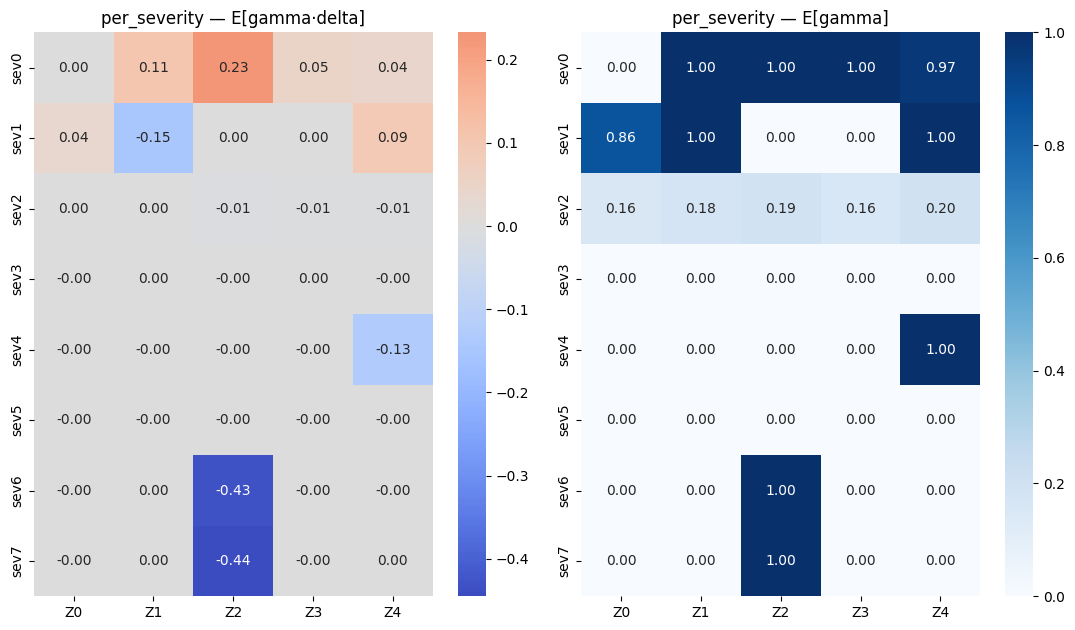

In [11]:
K = 5
PI = 0.3
MAX_ITER = 100
SEED = 0

data = load_covid(cohort_mode='per_severity', standardize=True)
print(f'N = {data.views.N}, D_metab = {data.views.simple[0].D}, D_prot = {data.views.simple[1].D}')
print('Cohort counts:')
print(pd.Series(data.cohorts).value_counts().sort_index().to_string())

m = fit_cohort(data.views, K=K, pi=PI, max_iter=MAX_ITER, seed=SEED)
mb = fit_baseline(data.views, K=K, max_iter=MAX_ITER, seed=SEED)
out = extract_cohort_effects(m, data.cohorts, K=K)
print(f"\nELBO  cohort = {out['elbo']:.1f},  baseline = {float(mb.elbo_sequence[-1]):.1f}")
plot_cohort_effects(out, K, 'per_severity')

fits['per_severity'] = {'data': data, 'cohort': m, 'baseline': mb, 'out': out}


## Experiment 2 — `grouped`: mild / moderate / severe

Clinical-style binning: `0-1` (mild), `2-4` (moderate), `5-7` (severe). Balances cohort
sizes (228 / 101 / 49) and aggregates the very small `sev2` class into `moderate`.


Cohort counts:
mild        228
moderate    101
severe       49
Pretraining FA
Fitting model


100%|██████████| 100/100 [01:12<00:00,  1.38it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [01:15<00:00,  1.32it/s]



ELBO  cohort = -676095.1,  baseline = -678148.2


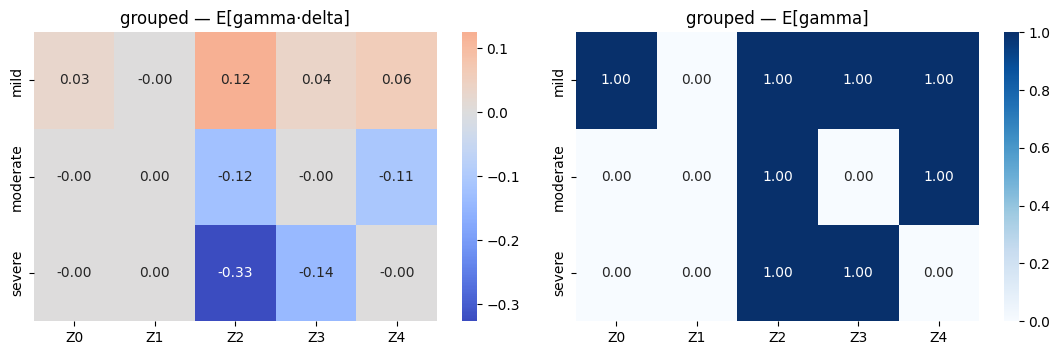

In [12]:
data = load_covid(cohort_mode='grouped', standardize=True)
print('Cohort counts:')
print(pd.Series(data.cohorts).value_counts().sort_index().to_string())

m = fit_cohort(data.views, K=K, pi=PI, max_iter=MAX_ITER, seed=SEED)
mb = fit_baseline(data.views, K=K, max_iter=MAX_ITER, seed=SEED)
out = extract_cohort_effects(m, data.cohorts, K=K)
print(f"\nELBO  cohort = {out['elbo']:.1f},  baseline = {float(mb.elbo_sequence[-1]):.1f}")
plot_cohort_effects(out, K, 'grouped')

fits['grouped'] = {'data': data, 'cohort': m, 'baseline': mb, 'out': out}


## Experiment 3 — `binary`: non_hosp vs hosp

Ordinal split at WHO scale = 3 (`0-2` vs `3-7`), i.e. non-hospitalised vs hospitalised.
Closest to a classical case/control design — the maximally simple cohort partition.


Cohort counts:
hosp        148
non_hosp    230
Pretraining FA
Fitting model


100%|██████████| 100/100 [01:12<00:00,  1.38it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [01:13<00:00,  1.37it/s]



ELBO  cohort = -676100.7,  baseline = -678148.2


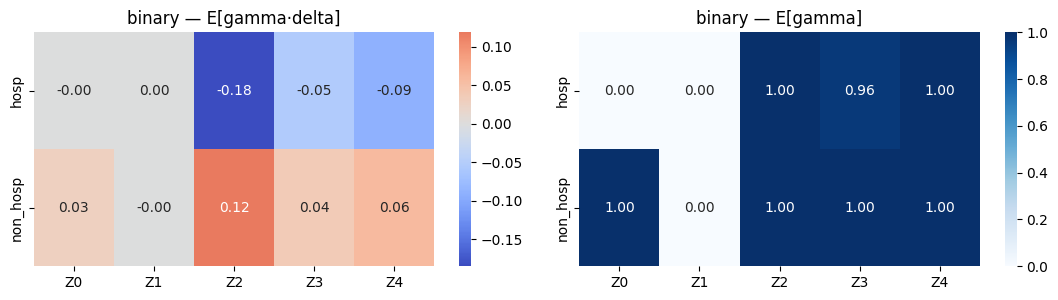

In [13]:
data = load_covid(cohort_mode='binary', standardize=True)
print('Cohort counts:')
print(pd.Series(data.cohorts).value_counts().sort_index().to_string())

m = fit_cohort(data.views, K=K, pi=PI, max_iter=MAX_ITER, seed=SEED)
mb = fit_baseline(data.views, K=K, max_iter=MAX_ITER, seed=SEED)
out = extract_cohort_effects(m, data.cohorts, K=K)
print(f"\nELBO  cohort = {out['elbo']:.1f},  baseline = {float(mb.elbo_sequence[-1]):.1f}")
plot_cohort_effects(out, K, 'binary')

fits['binary'] = {'data': data, 'cohort': m, 'baseline': mb, 'out': out}


## Experiment 4 — Cohort distance structure (latent L2 distances)

Adapted from `cohort_tests copy.ipynb` Exp 3 — but on real data, where the "truth" is
the WHO ordinal severity rather than a known `mu`. For each cohort partition we compute
pairwise L2 distances between cohort positions in latent space (`E[gamma·delta]`).

**What to look for:**
- `per_severity`: adjacent severities (e.g. `sev0`/`sev1`) should be closer than distant
  ones (`sev0`/`sev7`). Note that very small cohorts (`sev2`, ~2 samples) can produce
  unstable distances because their `gamma` is suppressed by the prior.
- `grouped`: `mild ↔ moderate` and `moderate ↔ severe` should each be smaller than
  `mild ↔ severe`.
- `binary`: a single scalar — magnitude indicates how strongly the model separates
  hospitalised vs non-hospitalised in latent space.


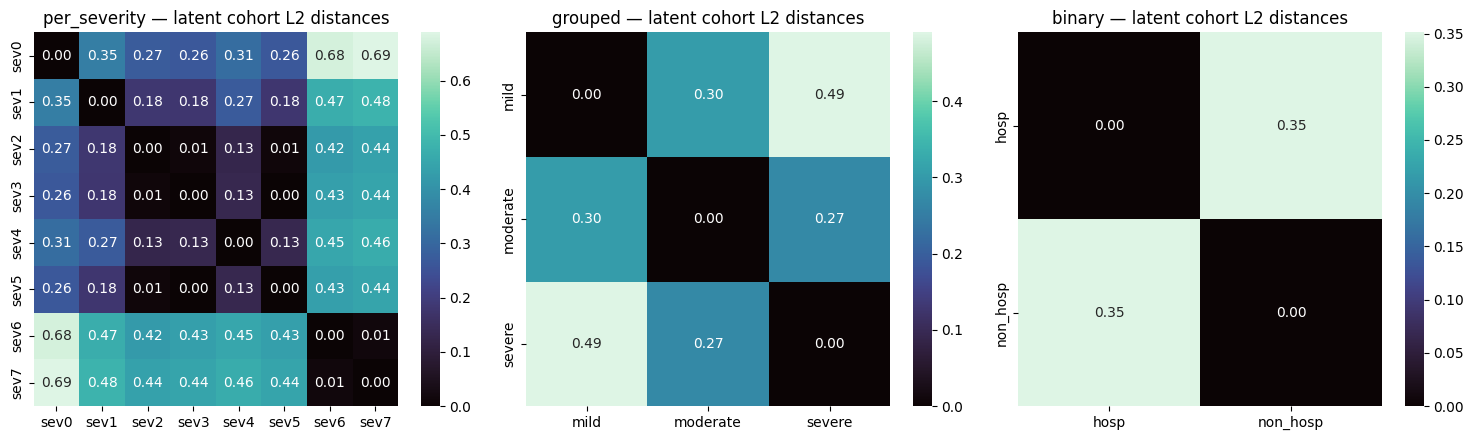

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mode in zip(axes, ['per_severity', 'grouped', 'binary']):
    out = fits[mode]['out']
    M = out['E_gamma'] * out['E_delta']     # (C, K) cohort positions in latent space
    D = cohort_dist(M)
    sns.heatmap(D, annot=True, fmt='.2f', cmap='mako',
                xticklabels=out['cohorts'], yticklabels=out['cohorts'], ax=ax)
    ax.set_title(f'{mode} — latent cohort L2 distances')
plt.tight_layout()
plt.show()


## Experiment 5 — Distance vs ordinal severity (the key distance test)

The most informative real-data analogue of `cohort_tests copy.ipynb` Exp 3/4: since the
WHO Ordinal Scale is genuinely ordinal, the model's cohort distances *should* correlate
with `|sev_i - sev_j|`. We compute that Pearson correlation on the upper triangle of the
distance matrix and compare cohort vs baseline.

- **Cohort row** uses `E[gamma·delta]` (the model's explicit cohort-position vector).
- **Baseline row** has no cohort positions, so we collapse to per-cohort means of `Z_hat`
  — this is the most natural baseline analogue and what the model would have to use if
  the cohort structure was not explicitly parametrised.

**Expected:** the cohort fit should match or exceed the baseline on `per_severity` and
`grouped`. The binary case is dropped (only 1 pair → correlation undefined). Even on
real data correlations can stay below 1.0 because (i) factor noise is large relative to
cohort offsets, (ii) several severities are very small and noisy.


In [34]:
rows = []
modes = ['grouped', 'per_severity']  # adjust as needed


def ensure_fit(mode):
    if mode in fits:
        return fits[mode]
    print(f"fits missing '{mode}'; fitting now.")
    data = load_covid(cohort_mode=mode, standardize=True)
    m = fit_cohort(data.views, K=K, pi=PI, max_iter=MAX_ITER, seed=SEED)
    mb = fit_baseline(data.views, K=K, max_iter=MAX_ITER, seed=SEED)
    out = extract_cohort_effects(m, data.cohorts, K=K)
    fits[mode] = {'data': data, 'cohort': m, 'baseline': mb, 'out': out}
    return fits[mode]


def safe_severity(label):
    try:
        return severity_from_label(label)
    except ValueError:
        s = str(label).strip().lower()
        if s in ('mild', 'moderate', 'severe'):
            return {'mild': 0.5, 'moderate': 3.0, 'severe': 6.0}[s]
        return float('nan')


for mode in modes:
    # Cohort model: use E[gamma·delta] as cohort positions
    pack = ensure_fit(mode)
    out = pack['out']
    M = out['E_gamma'] * out['E_delta']
    D_fit = cohort_dist(M)

    # Baseline model: per-cohort mean of Z_hat (best analogue without cohort prior)
    mb = pack['baseline']
    d = pack['data']
    Zh = mb.get_latent_factors()
    cohort_names = out['cohorts']
    Z_means = np.array([Zh[d.cohorts == c].mean(axis=0) for c in cohort_names])
    D_fit_b = cohort_dist(Z_means)

    # Ground-truth proxy: absolute severity difference
    sev = np.array([safe_severity(c) for c in cohort_names])
    D_sev = np.abs(sev[:, None] - sev[None, :])

    tri = np.triu_indices(len(cohort_names), 1)
    r_c = float(np.corrcoef(D_fit[tri], D_sev[tri])[0, 1])
    r_b = float(np.corrcoef(D_fit_b[tri], D_sev[tri])[0, 1])
    rows.append({'mode': mode, 'n_cohorts': len(cohort_names),
                 'dist_corr_cohort': r_c, 'dist_corr_baseline': r_b,
                 'gap (cohort - baseline)': r_c - r_b})

print(pd.DataFrame(rows).round(3).to_string(index=False))


fits missing 'per_severity'; fitting now.
Pretraining FA
Fitting model


100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [01:07<00:00,  1.48it/s]

        mode  n_cohorts  dist_corr_cohort  dist_corr_baseline  gap (cohort - baseline)
     grouped          3             0.957               0.930                    0.027
per_severity          8             0.651               0.774                   -0.123


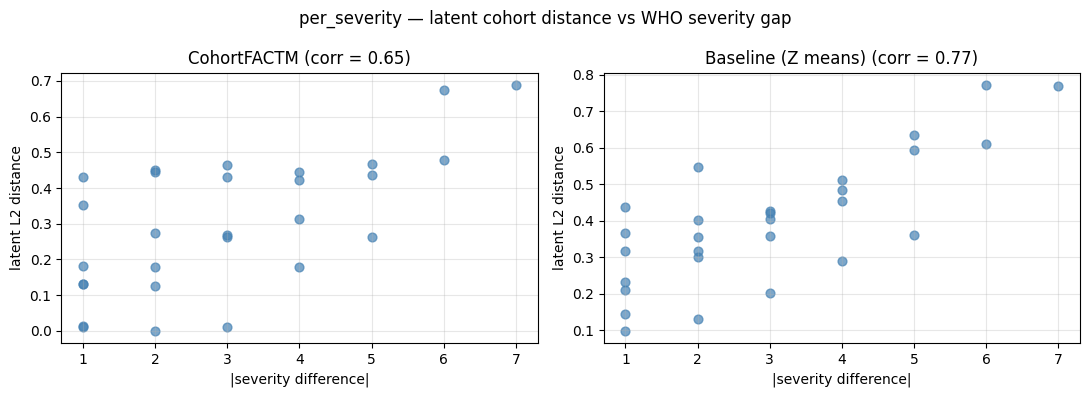

In [35]:
# Scatter: latent distance vs |severity| difference, cohort vs baseline (per_severity)
mode = 'per_severity'  # adjust as needed
out = fits[mode]['out']
mb = fits[mode]['baseline']
d = fits[mode]['data']

M = out['E_gamma'] * out['E_delta']
D_fit_c = cohort_dist(M)
Z_means = np.array([mb.get_latent_factors()[d.cohorts == c].mean(axis=0)
                    for c in out['cohorts']])
D_fit_b = cohort_dist(Z_means)

sev = np.array([severity_from_label(c) for c in out['cohorts']])
D_sev = np.abs(sev[:, None] - sev[None, :])
tri = np.triu_indices(len(out['cohorts']), 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, D_fit, label in zip(axes, [D_fit_c, D_fit_b], ['CohortFACTM', 'Baseline (Z means)']):
    r = float(np.corrcoef(D_fit[tri], D_sev[tri])[0, 1])
    ax.scatter(D_sev[tri], D_fit[tri], s=40, alpha=0.7, color='steelblue')
    ax.set_xlabel('|severity difference|')
    ax.set_ylabel('latent L2 distance')
    ax.set_title(f'{label} (corr = {r:.2f})')
    ax.grid(alpha=0.3)
plt.suptitle('per_severity — latent cohort distance vs WHO severity gap')
plt.tight_layout()
plt.show()


## Experiment 6 — W loadings stability (cohort vs baseline)

Adapted from `w_loading_tests.ipynb` SC4. On synthetic data SC4 asked whether the cohort
prior keeps `|corr(W_true, W_est)|` close to baseline as the cohort signal grows. With no
ground-truth `W` here, we instead ask the symmetric question:

> Does the cohort prior recover essentially the same feature loadings as the baseline,
> up to factor permutation and sign?

For each cohort partition we Hungarian-align factors on `Z`, then compute
`|corr(W_cohort, W_baseline)|` per factor per view. **High values** (≳0.9) mean the
cohort prior does not perturb the feature space and the cohort signal is absorbed
entirely into `gamma·delta`. **Low values** would suggest that cohort information is
also being absorbed into `W`, mixing latent cohort offsets with feature interpretation.


In [37]:
rows = []
per_factor_records = []
for mode in ['per_severity', 'grouped']:
    mc = fits[mode]['cohort']
    mb = fits[mode]['baseline']
    w_corrs, perm, signs = w_stability(mc, mb, K=K)
    for v, c in enumerate(w_corrs):
        view_name = 'metab' if v == 0 else 'prot'
        rows.append({'mode': mode, 'view': view_name,
                     'mean |corr| W': round(c.mean(), 3),
                     'min |corr| W':  round(c.min(),  3)})
        for k, val in enumerate(c):
            per_factor_records.append({'mode': mode, 'view': view_name,
                                       'factor': f'Z{k}', '|corr| W': val})

print(pd.DataFrame(rows).to_string(index=False))


        mode  view  mean |corr| W  min |corr| W
per_severity metab            1.0         1.000
per_severity  prot            1.0         0.999
     grouped metab            1.0         0.999
     grouped  prot            1.0         0.999


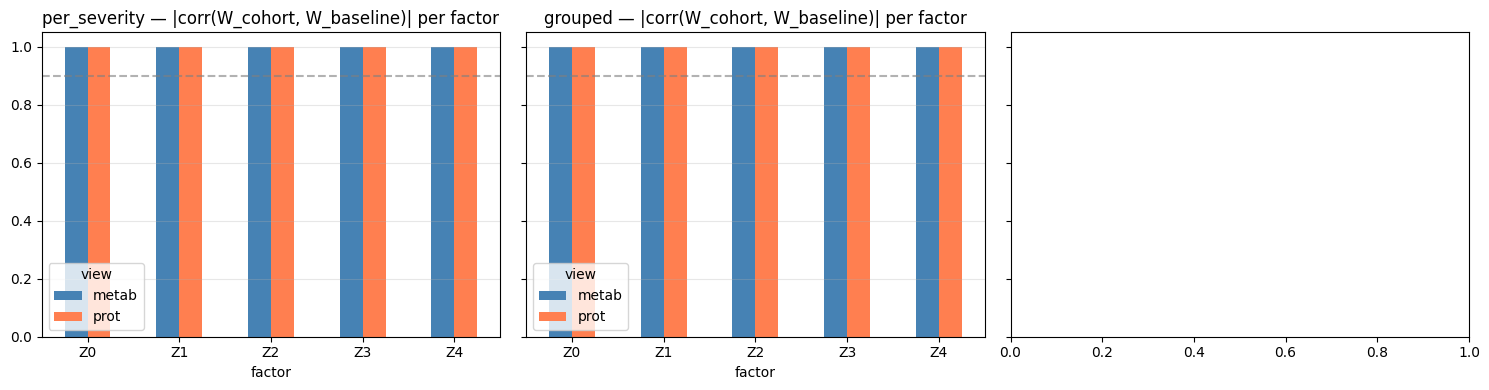

In [39]:
# Per-factor |corr|W bars, grouped by (mode, view)
df = pd.DataFrame(per_factor_records)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, mode in zip(axes, ['per_severity', 'grouped']):
    sub = df[df['mode'] == mode]
    pv = sub.pivot(index='factor', columns='view', values='|corr| W')
    pv.plot.bar(ax=ax, color=['steelblue', 'coral'], rot=0)
    ax.axhline(0.9, color='gray', linestyle='--', alpha=0.6)
    ax.set_title(f'{mode} — |corr(W_cohort, W_baseline)| per factor')
    ax.set_ylim([0, 1.05])
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
